## 🚀 AI Tools Ecosystem: Adoption, Popularity & Trend Analysis

#### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load the datasets

In [2]:
ai_tools = pd.read_csv("global_ai_tools_dataset_2026.csv")

In [3]:
ai_tools

,Tool_ID,Tool_Name,Category,Main_Function,Industry,Pricing_Model,Launch_Year,Popularity_Score,Last_Updated
0,1,ChatGPT,Chatbot,AI conversation and text generation,Technology,Freemium,2022,98,2026
1,2,Claude,Chatbot,AI assistant for writing and reasoning,Technology,Freemium,2023,92,2026
2,3,Google Gemini,Chatbot,Multimodal AI assistant,Technology,Freemium,2023,94,2026
3,4,Perplexity AI,Search AI,AI search engine assistant,Technology,Freemium,2022,90,2026
4,5,Midjourney,Image Generation,Generate images from prompts,Design,Paid,2022,91,2026
...,...,...,...,...,...,...,...,...,...
295,296,AI_Tool_296,Marketing AI,Marketing AI automation and assistance,Software Development,Freemium,2022,96,2026
296,297,AI_Tool_297,Writing Assistant,Writing Assistant automation and assistance,Technology,Paid,2023,97,2026
297,298,AI_Tool_298,Productivity,Productivity automation and assistance,Design,Free,2024,98,2026
298,299,AI_Tool_299,Research AI,Research AI automation and assistance,Media,Freemium,2025,99,2026


In [4]:
adoption = pd.read_csv("dataset.csv")

In [5]:
adoption

,country,industry,ai_tool,adoption_rate,daily_active_users,year,user_feedback,age_group,company_size
0,USA,Technology,ChatGPT,40.45,2461,2023,YyvLXOFyevRMSvJtkXodLvgejiqQNvSOZfeeJASDOVTxwm...,35-44,Startup
1,France,Manufacturing,Midjourney,35.72,8496,2024,AdFVhenjthYSKJNzxzfaGQk wLnjRCgrHTyfXQEFjFJCMO...,18-24,Enterprise
2,Australia,Transportation,ChatGPT,13.47,8641,2024,zgNPmXBICRNbpjpTqIUWmMTeTYsInDNtAmzuxpDvcUZEAi...,45-54,Startup
3,UK,Manufacturing,ChatGPT,48.46,3488,2023,LxeKzQFbPvhxXUSgPVlLLJ pUFaicjCgiMtAmsTjovkrdE...,45-54,Enterprise
4,UK,Agriculture,Stable Diffusion,34.06,1124,2024,IOQtQoSKdSmiXRsUKpjXjXZgQohymFkVUvOASXlEnVsIOS...,45-54,SME
...,...,...,...,...,...,...,...,...,...
144995,Australia,Agriculture,Midjourney,86.93,7921,2023,PxWkyTVwSNPoTXjsKzjbAFEfyJ MdgY CXjvSrkkHOTGcb...,18-24,SME
144996,Germany,Education,Midjourney,51.99,6301,2024,PtOmfGyWyZueDERRioCvbNgXomcpNNLFUjRuMEqeMrqR L...,45-54,SME
144997,USA,Finance,Stable Diffusion,47.35,4726,2023,VQuOdOKjRhchmEFrzvGlqsGOc fbTXzuzQzswt pZTCmhx...,45-54,Startup
144998,USA,Retail,ChatGPT,31.87,2481,2024,IRFOudTsoPrlrKypvToOx llYkLoLqrw EMHOtyAKmqXq...,25-34,Enterprise


#### Checks column names

In [6]:
ai_tools.columns

Index(['Tool_ID', 'Tool_Name', 'Category', 'Main_Function', 'Industry',
       'Pricing_Model', 'Launch_Year', 'Popularity_Score', 'Last_Updated'],
      dtype='str')

In [7]:
adoption.columns

Index(['country', 'industry', 'ai_tool', 'adoption_rate', 'daily_active_users',
       'year', 'user_feedback', 'age_group', 'company_size'],
      dtype='str')

### Checks whether dataset contains null values or not

In [8]:
ai_tools.isnull().sum() 

Tool_ID             0
Tool_Name           0
Category            0
Main_Function       0
Industry            0
Pricing_Model       0
Launch_Year         0
Popularity_Score    0
Last_Updated        0
dtype: int64

In [9]:
adoption.isnull().sum()

country               0
industry              0
ai_tool               0
adoption_rate         0
daily_active_users    0
year                  0
user_feedback         0
age_group             0
company_size          0
dtype: int64

### Checks whether dataset contains duplicates values or not

In [10]:
ai_tools.duplicated().sum()

np.int64(0)

In [11]:
adoption.duplicated().sum()

np.int64(0)

### Checks total unique values

In [12]:
print("Total AI Tools:", ai_tools["Tool_Name"].nunique())
print("Categories:", ai_tools["Category"].nunique())
print("Industries:", ai_tools["Industry"].nunique())
print("Pricing Models:", ai_tools["Pricing_Model"].nunique())

Total AI Tools: 300
Categories: 17
Industries: 7
Pricing Models: 3


In [13]:
print("Unique AI Tools:", adoption["ai_tool"].nunique())
print("Countries:", adoption["country"].nunique())
print("Industries:", adoption["industry"].nunique())
print("Age Groups:", adoption["age_group"].nunique())
print("Company Sizes:", adoption["company_size"].nunique())

Unique AI Tools: 5
Countries: 10
Industries: 8
Age Groups: 5
Company Sizes: 3


In [14]:
adoption["ai_tool"].unique()

<ArrowStringArray>
['ChatGPT', 'Midjourney', 'Stable Diffusion', 'Bard', 'Claude']
Length: 5, dtype: str

#### Converts all case letters in lower case and merge tools name from both datasets

In [15]:
master_tools = set(ai_tools["Tool_Name"].str.strip().str.lower())

adoption_tools = set(adoption["ai_tool"].str.strip().str.lower())

common_tools = master_tools.intersection(adoption_tools)

print("Common AI Tools:", len(common_tools))
print(common_tools)

Common AI Tools: 4
{'claude', 'midjourney', 'chatgpt', 'stable diffusion'}


#### Checking which tool present in both datasets

In [16]:
print("Adoption tools present in Master Dataset:")

for tool in adoption["ai_tool"].unique():
    match = ai_tools[
        ai_tools["Tool_Name"].str.strip().str.lower() == tool.strip().lower()
    ]
    print(tool, "→", len(match))

Adoption tools present in Master Dataset:
ChatGPT → 1
Midjourney → 1
Stable Diffusion → 1
Bard → 0
Claude → 1


#### Create a common Tools_Name column in both tables for matching both datasets

In [17]:
ai_tools["Tools_Name"] = ai_tools["Tool_Name"].str.strip().str.lower()
adoption["Tools_Name"] = adoption["ai_tool"].str.strip().str.lower()

print("Tool keys created successfully.")

Tool keys created successfully.


In [18]:
ai_tools

,Tool_ID,Tool_Name,Category,Main_Function,Industry,Pricing_Model,Launch_Year,Popularity_Score,Last_Updated,Tools_Name
0,1,ChatGPT,Chatbot,AI conversation and text generation,Technology,Freemium,2022,98,2026,chatgpt
1,2,Claude,Chatbot,AI assistant for writing and reasoning,Technology,Freemium,2023,92,2026,claude
2,3,Google Gemini,Chatbot,Multimodal AI assistant,Technology,Freemium,2023,94,2026,google gemini
3,4,Perplexity AI,Search AI,AI search engine assistant,Technology,Freemium,2022,90,2026,perplexity ai
4,5,Midjourney,Image Generation,Generate images from prompts,Design,Paid,2022,91,2026,midjourney
...,...,...,...,...,...,...,...,...,...,...
295,296,AI_Tool_296,Marketing AI,Marketing AI automation and assistance,Software Development,Freemium,2022,96,2026,ai_tool_296
296,297,AI_Tool_297,Writing Assistant,Writing Assistant automation and assistance,Technology,Paid,2023,97,2026,ai_tool_297
297,298,AI_Tool_298,Productivity,Productivity automation and assistance,Design,Free,2024,98,2026,ai_tool_298
298,299,AI_Tool_299,Research AI,Research AI automation and assistance,Media,Freemium,2025,99,2026,ai_tool_299


#### Rename industry column with tool_industry in ai_tools and adoption_industry in adoption dataset

In [19]:
ai_tools = ai_tools.rename(columns={
    "Industry": "tool_industry"
})

adoption = adoption.rename(columns={
    "industry": "adoption_industry"
})

In [20]:
ai_tools

,Tool_ID,Tool_Name,Category,Main_Function,tool_industry,Pricing_Model,Launch_Year,Popularity_Score,Last_Updated,Tools_Name
0,1,ChatGPT,Chatbot,AI conversation and text generation,Technology,Freemium,2022,98,2026,chatgpt
1,2,Claude,Chatbot,AI assistant for writing and reasoning,Technology,Freemium,2023,92,2026,claude
2,3,Google Gemini,Chatbot,Multimodal AI assistant,Technology,Freemium,2023,94,2026,google gemini
3,4,Perplexity AI,Search AI,AI search engine assistant,Technology,Freemium,2022,90,2026,perplexity ai
4,5,Midjourney,Image Generation,Generate images from prompts,Design,Paid,2022,91,2026,midjourney
...,...,...,...,...,...,...,...,...,...,...
295,296,AI_Tool_296,Marketing AI,Marketing AI automation and assistance,Software Development,Freemium,2022,96,2026,ai_tool_296
296,297,AI_Tool_297,Writing Assistant,Writing Assistant automation and assistance,Technology,Paid,2023,97,2026,ai_tool_297
297,298,AI_Tool_298,Productivity,Productivity automation and assistance,Design,Free,2024,98,2026,ai_tool_298
298,299,AI_Tool_299,Research AI,Research AI automation and assistance,Media,Freemium,2025,99,2026,ai_tool_299


In [21]:
adoption.drop(columns=["user_feedback"])

,country,adoption_industry,ai_tool,adoption_rate,daily_active_users,year,age_group,company_size,Tools_Name
0,USA,Technology,ChatGPT,40.45,2461,2023,35-44,Startup,chatgpt
1,France,Manufacturing,Midjourney,35.72,8496,2024,18-24,Enterprise,midjourney
2,Australia,Transportation,ChatGPT,13.47,8641,2024,45-54,Startup,chatgpt
3,UK,Manufacturing,ChatGPT,48.46,3488,2023,45-54,Enterprise,chatgpt
4,UK,Agriculture,Stable Diffusion,34.06,1124,2024,45-54,SME,stable diffusion
...,...,...,...,...,...,...,...,...,...
144995,Australia,Agriculture,Midjourney,86.93,7921,2023,18-24,SME,midjourney
144996,Germany,Education,Midjourney,51.99,6301,2024,45-54,SME,midjourney
144997,USA,Finance,Stable Diffusion,47.35,4726,2023,45-54,Startup,stable diffusion
144998,USA,Retail,ChatGPT,31.87,2481,2024,25-34,Enterprise,chatgpt


#### Merged two datasets in single

In [22]:
merged = adoption.merge(
    ai_tools,
    on="Tools_Name",
    how="left"
)

In [23]:
print("Merged Dataset Shape:", merged.shape)

print("\nMissing Master Tool Names:")
print(merged["Tool_Name"].isna().sum())

Merged Dataset Shape: (145000, 19)

Missing Master Tool Names:
14519


In [24]:
print(
    merged[merged["Tool_Name"].isna()]["ai_tool"].value_counts()
)

ai_tool
Bard    14519
Name: count, dtype: int64


In [25]:
ai_tools.drop(columns=["Tools_Name"])

,Tool_ID,Tool_Name,Category,Main_Function,tool_industry,Pricing_Model,Launch_Year,Popularity_Score,Last_Updated
0,1,ChatGPT,Chatbot,AI conversation and text generation,Technology,Freemium,2022,98,2026
1,2,Claude,Chatbot,AI assistant for writing and reasoning,Technology,Freemium,2023,92,2026
2,3,Google Gemini,Chatbot,Multimodal AI assistant,Technology,Freemium,2023,94,2026
3,4,Perplexity AI,Search AI,AI search engine assistant,Technology,Freemium,2022,90,2026
4,5,Midjourney,Image Generation,Generate images from prompts,Design,Paid,2022,91,2026
...,...,...,...,...,...,...,...,...,...
295,296,AI_Tool_296,Marketing AI,Marketing AI automation and assistance,Software Development,Freemium,2022,96,2026
296,297,AI_Tool_297,Writing Assistant,Writing Assistant automation and assistance,Technology,Paid,2023,97,2026
297,298,AI_Tool_298,Productivity,Productivity automation and assistance,Design,Free,2024,98,2026
298,299,AI_Tool_299,Research AI,Research AI automation and assistance,Media,Freemium,2025,99,2026


In [26]:
merged

,country,adoption_industry,ai_tool,adoption_rate,daily_active_users,year,user_feedback,age_group,company_size,Tools_Name,Tool_ID,Tool_Name,Category,Main_Function,tool_industry,Pricing_Model,Launch_Year,Popularity_Score,Last_Updated
0,USA,Technology,ChatGPT,40.45,2461,2023,YyvLXOFyevRMSvJtkXodLvgejiqQNvSOZfeeJASDOVTxwm...,35-44,Startup,chatgpt,1.0,ChatGPT,Chatbot,AI conversation and text generation,Technology,Freemium,2022.0,98.0,2026.0
1,France,Manufacturing,Midjourney,35.72,8496,2024,AdFVhenjthYSKJNzxzfaGQk wLnjRCgrHTyfXQEFjFJCMO...,18-24,Enterprise,midjourney,5.0,Midjourney,Image Generation,Generate images from prompts,Design,Paid,2022.0,91.0,2026.0
2,Australia,Transportation,ChatGPT,13.47,8641,2024,zgNPmXBICRNbpjpTqIUWmMTeTYsInDNtAmzuxpDvcUZEAi...,45-54,Startup,chatgpt,1.0,ChatGPT,Chatbot,AI conversation and text generation,Technology,Freemium,2022.0,98.0,2026.0
3,UK,Manufacturing,ChatGPT,48.46,3488,2023,LxeKzQFbPvhxXUSgPVlLLJ pUFaicjCgiMtAmsTjovkrdE...,45-54,Enterprise,chatgpt,1.0,ChatGPT,Chatbot,AI conversation and text generation,Technology,Freemium,2022.0,98.0,2026.0
4,UK,Agriculture,Stable Diffusion,34.06,1124,2024,IOQtQoSKdSmiXRsUKpjXjXZgQohymFkVUvOASXlEnVsIOS...,45-54,SME,stable diffusion,7.0,Stable Diffusion,Image Generation,Open source image generator,Design,Free,2022.0,88.0,2026.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144995,Australia,Agriculture,Midjourney,86.93,7921,2023,PxWkyTVwSNPoTXjsKzjbAFEfyJ MdgY CXjvSrkkHOTGcb...,18-24,SME,midjourney,5.0,Midjourney,Image Generation,Generate images from prompts,Design,Paid,2022.0,91.0,2026.0
144996,Germany,Education,Midjourney,51.99,6301,2024,PtOmfGyWyZueDERRioCvbNgXomcpNNLFUjRuMEqeMrqR L...,45-54,SME,midjourney,5.0,Midjourney,Image Generation,Generate images from prompts,Design,Paid,2022.0,91.0,2026.0
144997,USA,Finance,Stable Diffusion,47.35,4726,2023,VQuOdOKjRhchmEFrzvGlqsGOc fbTXzuzQzswt pZTCmhx...,45-54,Startup,stable diffusion,7.0,Stable Diffusion,Image Generation,Open source image generator,Design,Free,2022.0,88.0,2026.0
144998,USA,Retail,ChatGPT,31.87,2481,2024,IRFOudTsoPrlrKypvToOx llYkLoLqrw EMHOtyAKmqXq...,25-34,Enterprise,chatgpt,1.0,ChatGPT,Chatbot,AI conversation and text generation,Technology,Freemium,2022.0,98.0,2026.0


In [27]:
merged.columns

Index(['country', 'adoption_industry', 'ai_tool', 'adoption_rate',
       'daily_active_users', 'year', 'user_feedback', 'age_group',
       'company_size', 'Tools_Name', 'Tool_ID', 'Tool_Name', 'Category',
       'Main_Function', 'tool_industry', 'Pricing_Model', 'Launch_Year',
       'Popularity_Score', 'Last_Updated'],
      dtype='str')

#### Drop unnecessary columns from merged dataset

In [28]:
merged = merged.drop(
    columns=["Tools_Name", "Tool_Name", "user_feedback"]
)

In [29]:
merged

,country,adoption_industry,ai_tool,adoption_rate,daily_active_users,year,age_group,company_size,Tool_ID,Category,Main_Function,tool_industry,Pricing_Model,Launch_Year,Popularity_Score,Last_Updated
0,USA,Technology,ChatGPT,40.45,2461,2023,35-44,Startup,1.0,Chatbot,AI conversation and text generation,Technology,Freemium,2022.0,98.0,2026.0
1,France,Manufacturing,Midjourney,35.72,8496,2024,18-24,Enterprise,5.0,Image Generation,Generate images from prompts,Design,Paid,2022.0,91.0,2026.0
2,Australia,Transportation,ChatGPT,13.47,8641,2024,45-54,Startup,1.0,Chatbot,AI conversation and text generation,Technology,Freemium,2022.0,98.0,2026.0
3,UK,Manufacturing,ChatGPT,48.46,3488,2023,45-54,Enterprise,1.0,Chatbot,AI conversation and text generation,Technology,Freemium,2022.0,98.0,2026.0
4,UK,Agriculture,Stable Diffusion,34.06,1124,2024,45-54,SME,7.0,Image Generation,Open source image generator,Design,Free,2022.0,88.0,2026.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144995,Australia,Agriculture,Midjourney,86.93,7921,2023,18-24,SME,5.0,Image Generation,Generate images from prompts,Design,Paid,2022.0,91.0,2026.0
144996,Germany,Education,Midjourney,51.99,6301,2024,45-54,SME,5.0,Image Generation,Generate images from prompts,Design,Paid,2022.0,91.0,2026.0
144997,USA,Finance,Stable Diffusion,47.35,4726,2023,45-54,Startup,7.0,Image Generation,Open source image generator,Design,Free,2022.0,88.0,2026.0
144998,USA,Retail,ChatGPT,31.87,2481,2024,25-34,Enterprise,1.0,Chatbot,AI conversation and text generation,Technology,Freemium,2022.0,98.0,2026.0


In [30]:
merged.columns

Index(['country', 'adoption_industry', 'ai_tool', 'adoption_rate',
       'daily_active_users', 'year', 'age_group', 'company_size', 'Tool_ID',
       'Category', 'Main_Function', 'tool_industry', 'Pricing_Model',
       'Launch_Year', 'Popularity_Score', 'Last_Updated'],
      dtype='str')

In [31]:
print("Rows:", merged.shape[0])
print("Columns:", merged.shape[1])

print("\nMissing Values:")
print(merged.isnull().sum())

Rows: 145000
Columns: 16

Missing Values:
country                   0
adoption_industry         0
ai_tool                   0
adoption_rate             0
daily_active_users        0
year                      0
age_group                 0
company_size              0
Tool_ID               14519
Category              14519
Main_Function         14519
tool_industry         14519
Pricing_Model         14519
Launch_Year           14519
Popularity_Score      14519
Last_Updated          14519
dtype: int64


In [32]:
merged.groupby("ai_tool")["Popularity_Score"].apply(
    lambda x: x.notna().sum()
)

ai_tool
Bard                    0
ChatGPT             58045
Claude               7286
Midjourney          43324
Stable Diffusion    21826
Name: Popularity_Score, dtype: int64

## PROBLEM STATEMENTS

### Problem Statement 1 : AI Tool Distribution Across Categories
This analysis examines how the 300 AI tools in the dataset are distributed across different AI categories. It helps identify which areas of AI have the largest representation in the ecosystem.

In [33]:
category_counts = ai_tools["Category"].value_counts()

In [34]:
category_counts

Category
Image Generation     31
Coding Assistant     31
Chatbot              30
Video AI             30
Writing Assistant    29
Marketing AI         29
Voice AI             29
Productivity         28
Research AI          27
Data Science AI      27
AI Platform           2
Design AI             2
Search AI             1
Translation AI        1
Meeting AI            1
Audio AI              1
3D AI                 1
Name: count, dtype: int64

In [35]:
# Converted category_counts ito dataframe because we have to make chart of that
category_df = category_counts.reset_index()

category_df.columns = ["Category", "Tool_Count"]

print(category_df)

             Category  Tool_Count
0    Image Generation          31
1    Coding Assistant          31
2             Chatbot          30
3            Video AI          30
4   Writing Assistant          29
5        Marketing AI          29
6            Voice AI          29
7        Productivity          28
8         Research AI          27
9     Data Science AI          27
10        AI Platform           2
11          Design AI           2
12          Search AI           1
13     Translation AI           1
14         Meeting AI           1
15           Audio AI           1
16              3D AI           1


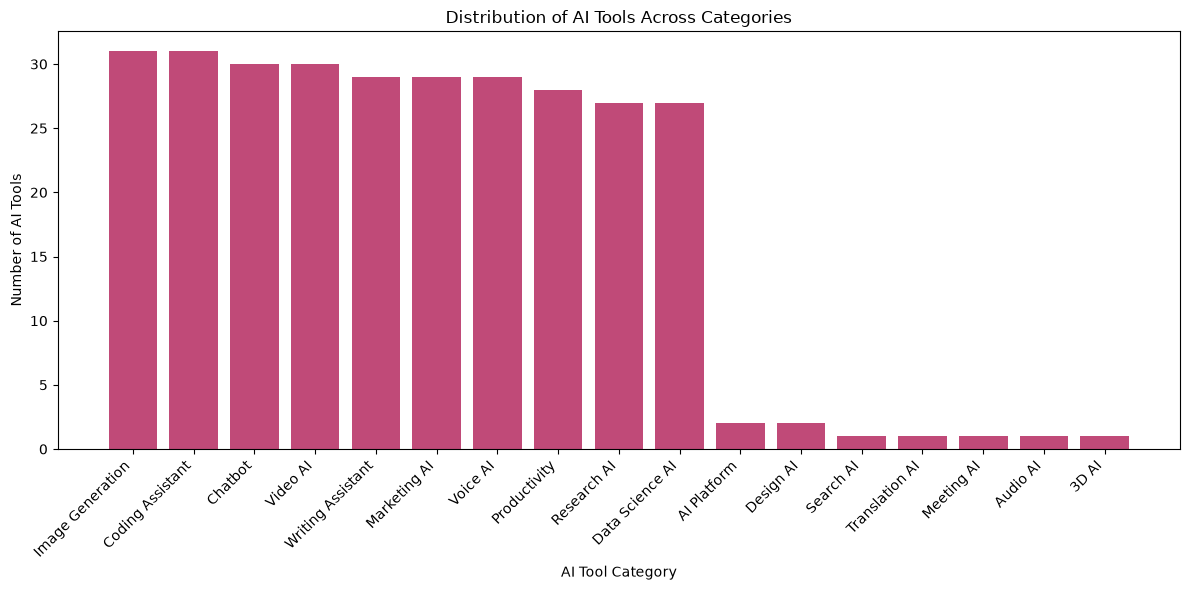

In [36]:
plt.figure(figsize=(12, 6))

plt.bar(
    category_df["Category"],
    category_df["Tool_Count"],
    color= "#C04A78"
)

plt.title("Distribution of AI Tools Across Categories")
plt.xlabel("AI Tool Category")
plt.ylabel("Number of AI Tools")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Key Insight

The dataset contains 300 AI tools across 17 categories. Image Generation and Coding Assistant have the highest number of tools, followed by Chatbot and Video AI. In comparison, categories such as Search AI, Translation AI, Meeting AI, Audio AI, and 3D AI have very few tools in the dataset.

### Problem Statement 2 : AI Tool Popularity Analysis

This analysis examines the popularity scores of AI tools in the dataset. It helps identify the most popular AI tools and understand which tools have the highest representation based on their popularity scores.

In [37]:
top_10_popular = ai_tools[
    ["Tool_Name", "Category", "Popularity_Score"]
].sort_values(
    by="Popularity_Score",
    ascending=False
).head(10)
top_10_popular

,Tool_Name,Category,Popularity_Score
298,AI_Tool_299,Research AI,99
268,AI_Tool_269,Research AI,99
238,AI_Tool_239,Research AI,99
208,AI_Tool_209,Research AI,99
58,AI_Tool_59,Research AI,99
88,AI_Tool_89,Research AI,99
118,AI_Tool_119,Research AI,99
148,AI_Tool_149,Research AI,99
178,AI_Tool_179,Research AI,99
207,AI_Tool_208,Productivity,98


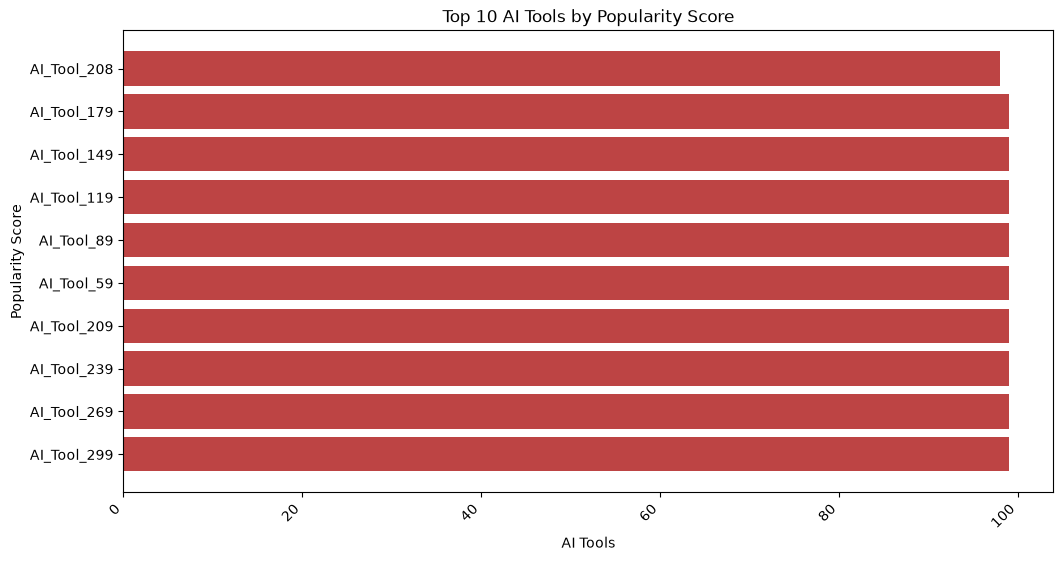

In [38]:
plt.figure(figsize=(12,6))

plt.barh(top_10_popular["Tool_Name"], top_10_popular["Popularity_Score"], color="#BD4444")

plt.title("Top 10 AI Tools by Popularity Score")
plt.xlabel("AI Tools")
plt.ylabel("Popularity Score")
plt.xticks(rotation=45, ha="right")
plt.show()

Key Insight:

Research AI tools have the highest popularity scores, with several tools scoring 99. The top 10 tools have popularity scores between 98 and 99.

### Problem Statement 3 : AI Tools by Pricing Model and Industry

How are AI tools distributed across different pricing models and industries?

Analysis:

This analysis examines how AI tools are distributed across different pricing models and industries. It helps understand the availability of AI tools under different pricing structures and their representation across various industries.

In [39]:
pricing_industry = pd.crosstab(
    ai_tools["tool_industry"],
    ai_tools["Pricing_Model"]
)

pricing_industry

Pricing_Model,Free,Freemium,Paid
tool_industry,,,
Design,14,18,14
Education,13,16,13
Marketing,12,14,14
Media,13,17,15
Productivity,13,14,13
Software Development,14,14,14
Technology,15,17,13


<Figure size 1200x600 with 0 Axes>

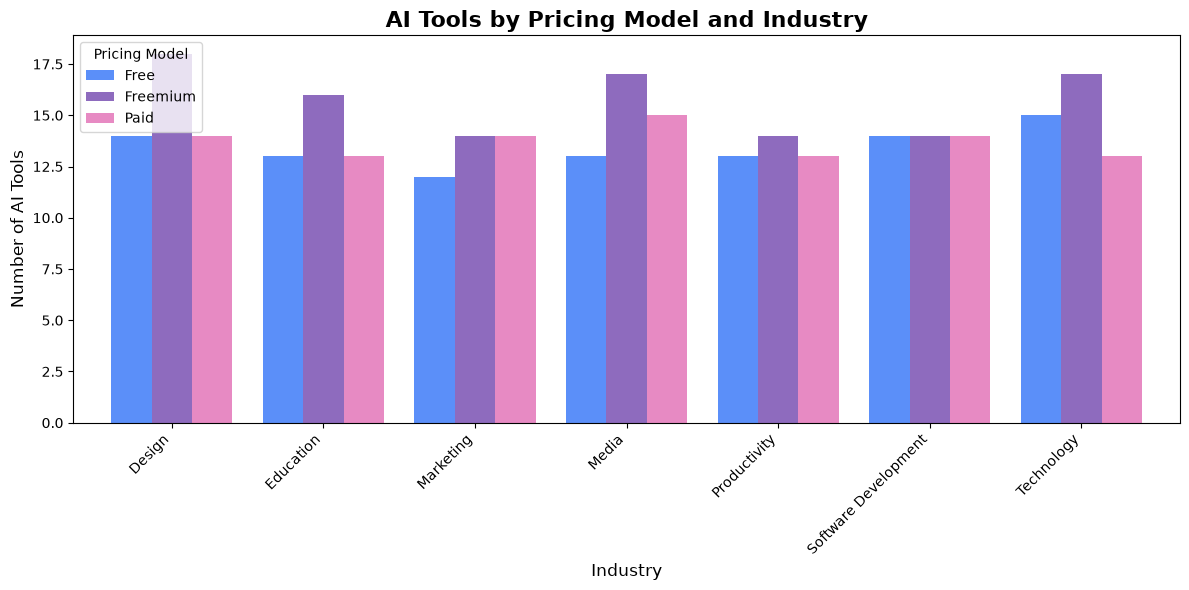

In [40]:
plt.figure(figsize=(12, 6))

pricing_industry.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    color=["#5B8FF9", "#8E6BBE", "#E78AC3"]
)

plt.title("AI Tools by Pricing Model and Industry", fontsize=16, fontweight="bold")
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Number of AI Tools", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Pricing Model")

plt.tight_layout()
plt.show()

Key Insight:

The distribution of AI tools varies across industries and pricing models, with some industries having more Free, Freemium, or Paid tools than others.

### Problem Statement 4 : AI Ecosystem Growth Analysis

How has the AI tool ecosystem evolved based on tool launch years?

Analysis:

This analysis examines the number of AI tools launched across different years. It helps identify periods of increased AI tool development and understand how the AI ecosystem has evolved over time.

In [41]:
yearly_tools = ai_tools["Launch_Year"].value_counts().sort_index()

yearly_tools

Launch_Year
2010     1
2016     2
2017     2
2018     1
2019     2
2020    47
2021    51
2022    52
2023    52
2024    45
2025    45
Name: count, dtype: int64

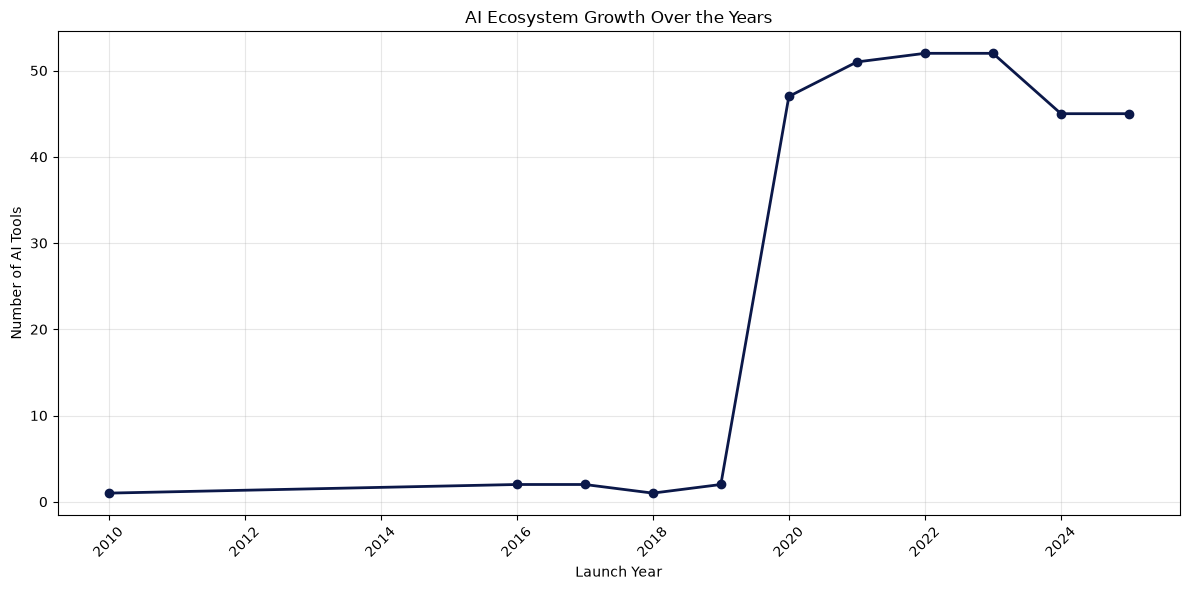

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_tools.index,
    yearly_tools.values,
    marker="o",
    color="#0B1849",
    linewidth=2
)

plt.title("AI Ecosystem Growth Over the Years")
plt.xlabel("Launch Year")
plt.ylabel("Number of AI Tools")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Key Insight:

The number of AI tools varies across launch years, with some years showing higher tool development than others. This indicates the AI ecosystem has grown over time.

### Problem Statement 5 : AI Tool Usage Trends Over the Years

Which AI tools show the highest usage over the years, and how does their adoption change over time?

Analysis:

This analysis examines the adoption of different AI tools over the years. It helps identify which AI tools have higher adoption rates and how their adoption changes over time.

In [43]:
yearly_adoption = (
    adoption.groupby(["year", "ai_tool"])["adoption_rate"]
    .mean()
    .reset_index()
)

yearly_adoption

,year,ai_tool,adoption_rate
0,2023,Bard,49.807776
1,2023,ChatGPT,49.997590
2,2023,Claude,50.035480
3,2023,Midjourney,50.219806
4,2023,Stable Diffusion,49.832386
5,2024,Bard,49.815614
6,2024,ChatGPT,49.872258
7,2024,Claude,50.262959
8,2024,Midjourney,49.760481
9,2024,Stable Diffusion,49.588063


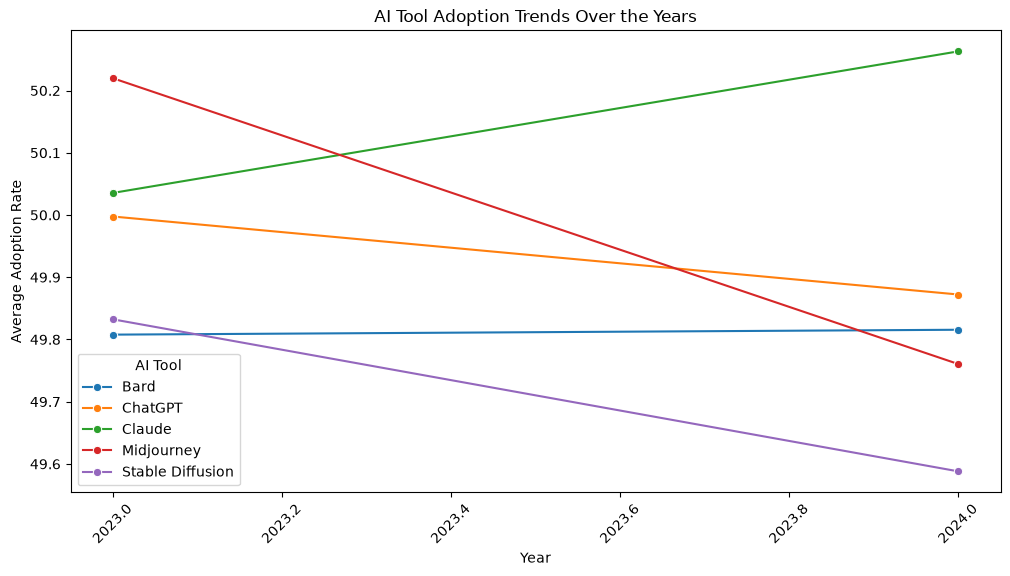

In [44]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_adoption,
    x="year",
    y="adoption_rate",
    hue="ai_tool",
    marker="o"
)

plt.title("AI Tool Adoption Trends Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Adoption Rate")
plt.legend(title="AI Tool")
plt.xticks(rotation=45)

plt.show()

Key Insight:

The adoption rate of AI tools changes over the years, with some tools showing consistently higher adoption than others. This helps identify the AI tools that have stronger adoption patterns and how their usage changes over time.

### Problem Statement 6 : AI Adoption Across Countries and User Segments

How does AI tool adoption vary across countries, industries, age groups, and company sizes?

Analysis:

This analysis examines AI tool adoption across different countries, industries, age groups, and company sizes. It helps identify variations in adoption patterns across geographical locations and different user and organizational segments.

In [45]:
country_industry = pd.pivot_table(
    adoption,
    values="adoption_rate",
    index="adoption_industry",
    columns="country",
    aggfunc="mean"
)

country_industry

country,Australia,Brazil,Canada,China,France,Germany,India,South Korea,UK,USA
adoption_industry,,,,,,,,,,
Agriculture,49.868118,49.805014,49.538573,51.401234,50.801913,50.569821,50.932527,50.559287,49.899184,49.961879
Education,49.670448,50.228730,49.673006,49.675482,49.903614,49.572518,49.797531,49.371145,50.414145,49.604809
Finance,50.372199,50.912366,49.756445,49.171850,49.788796,50.636569,49.939473,49.688724,50.172426,49.192160
Healthcare,50.316913,49.364489,49.363784,49.880782,49.306187,51.594473,50.600459,50.132282,49.371705,48.857886
Manufacturing,50.550195,49.575323,50.577037,49.717245,49.083480,50.261548,49.320939,50.035205,48.039631,48.568338
Retail,48.872760,49.430752,49.715220,49.244822,49.620394,50.052662,50.167088,49.826244,49.939670,49.221568
Technology,50.252685,51.157447,50.145538,48.399281,49.794844,50.206399,49.351848,50.054232,49.728637,51.028526
Transportation,50.049854,49.362225,50.617750,49.527137,50.040941,48.536015,50.457489,49.451248,50.757712,49.599301


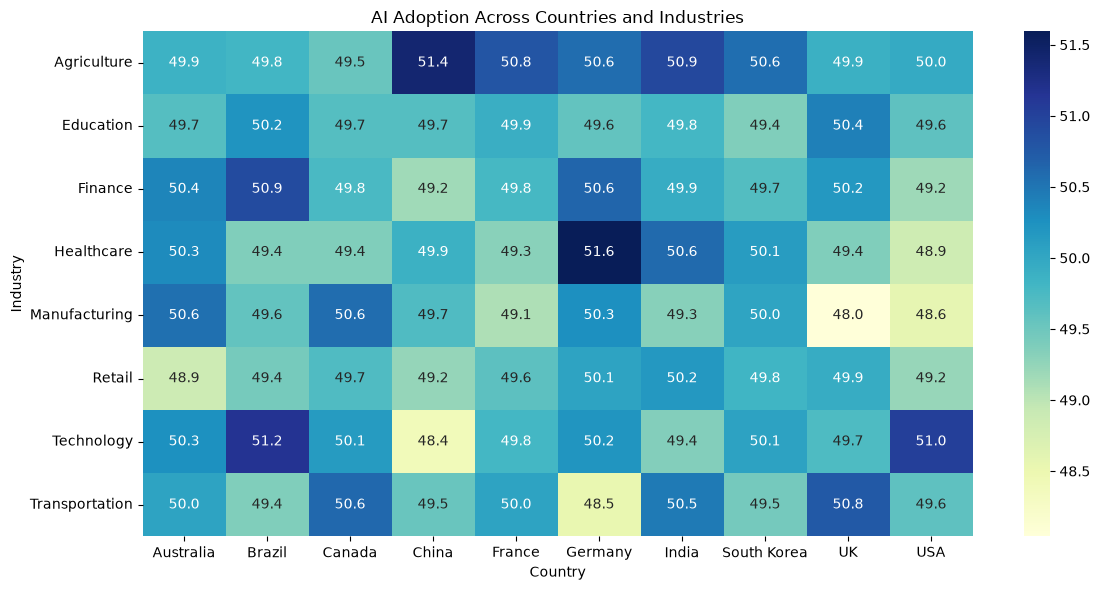

In [46]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    country_industry,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("AI Adoption Across Countries and Industries")
plt.xlabel("Country")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

### Problem Statement 7 : AI Adoption Trends and Popularity Relationship

How has AI tool adoption changed over the years, and is there a relationship between popularity score and adoption metrics?

Analysis:

This analysis examines changes in AI tool adoption over time and explores the relationship between popularity scores and adoption-related metrics. It helps understand whether tools with higher popularity scores also show differences in adoption patterns within the available data.

In [49]:
tool_adoption = (adoption.groupby("ai_tool")["adoption_rate"].mean().reset_index())
tool_adoption

,ai_tool,adoption_rate
0,Bard,49.813313
1,ChatGPT,49.909742
2,Claude,50.196582
3,Midjourney,49.896495
4,Stable Diffusion,49.660500


In [52]:
popularity_adoption = tool_adoption.merge(ai_tools[["Tool_Name", "Popularity_Score"]],  left_on="ai_tool", right_on="Tool_Name", how="inner")
popularity_adoption

,ai_tool,adoption_rate,Tool_Name,Popularity_Score
0,ChatGPT,49.909742,ChatGPT,98
1,Claude,50.196582,Claude,92
2,Midjourney,49.896495,Midjourney,91
3,Stable Diffusion,49.660500,Stable Diffusion,88


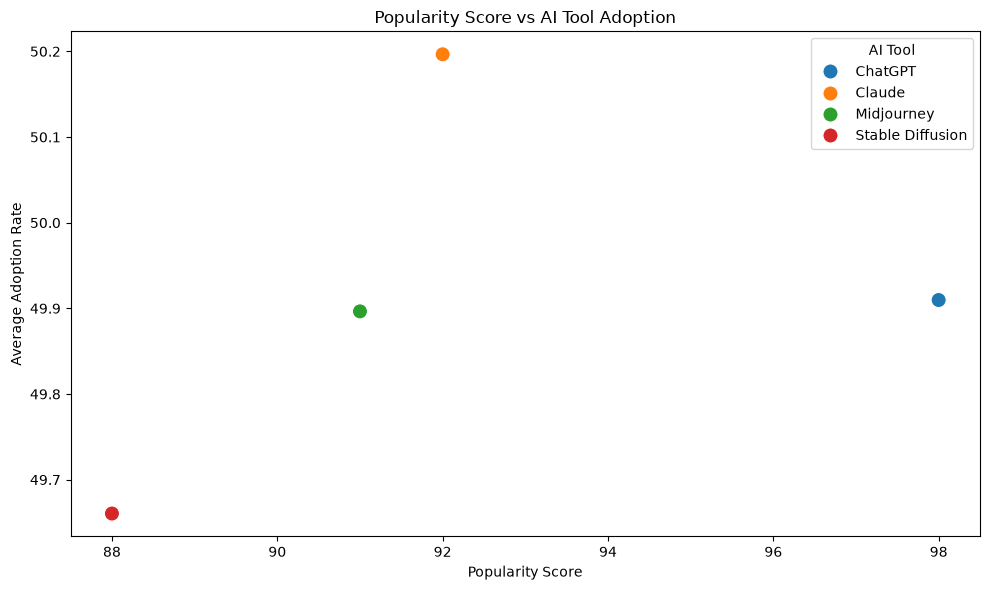

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=popularity_adoption,  x="Popularity_Score", y="adoption_rate", hue="ai_tool", s=120)
plt.title("Popularity Score vs AI Tool Adoption")
plt.xlabel("Popularity Score")
plt.ylabel("Average Adoption Rate")
plt.legend(title="AI Tool")
plt.tight_layout()
plt.show()

**Key Insight:**\n\nThe scatter plot shows the relationship between popularity scores and average adoption rates of AI tools. It helps identify whether tools with higher popularity scores also tend to have higher adoption rates within the available dataset.\n\n**Note:**\n\nThe relationship is based on the available popularity score and average adoption rate data. Since the datasets have only a limited number of matched AI tools, the result should be interpreted within the scope of this dataset.

### Problem Statement 8 : AI Tool Usage by Main Function

Which AI tools are most commonly associated with different main functions?

Analysis:

This analysis examines the relationship between AI tools and their main functions. It helps identify which AI tools are associated with different functions and understand the functional usage patterns of AI tools.

In [54]:
function_counts = ai_tools["Main_Function"].value_counts()

function_counts

Main_Function
Chatbot automation and assistance              27
Image Generation automation and assistance     27
Video AI automation and assistance             27
Voice AI automation and assistance             27
Coding Assistant automation and assistance     27
Marketing AI automation and assistance         27
Writing Assistant automation and assistance    27
Productivity automation and assistance         27
Research AI automation and assistance          27
Data Science AI automation and assistance      27
AI conversation and text generation             1
AI assistant for writing and reasoning          1
Multimodal AI assistant                         1
AI search engine assistant                      1
Generate images from prompts                    1
AI image generation from text                   1
Open source image generator                     1
AI video generation and editing                 1
AI avatar video creation                        1
Convert text into videos            

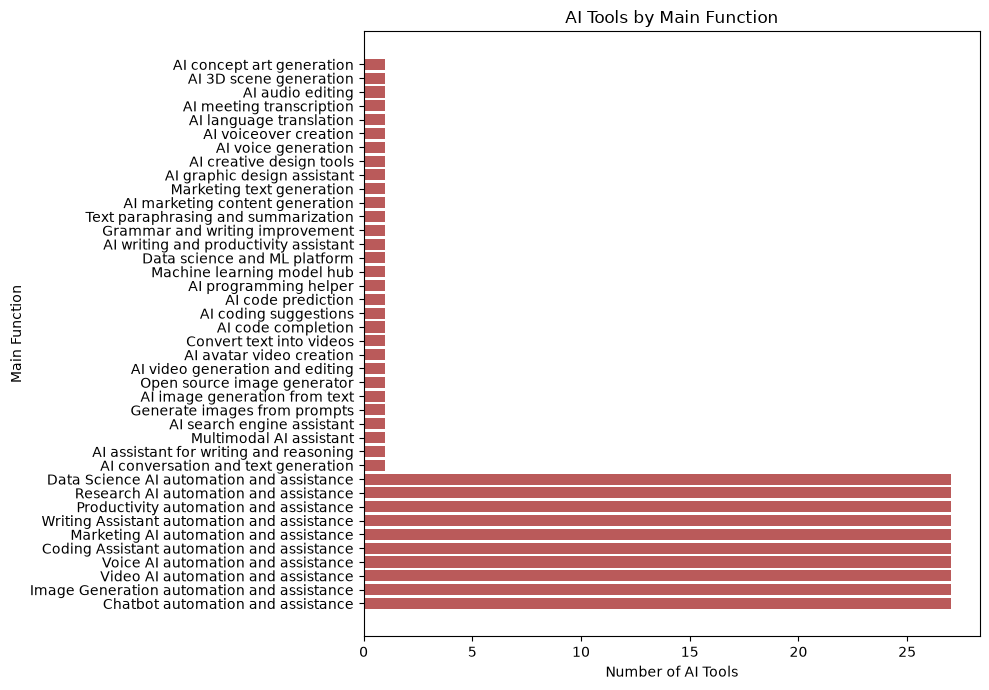

In [55]:
plt.figure(figsize=(10, 7))

plt.barh(
    function_counts.index,
    function_counts.values,
    color="#BA5A5A"
)

plt.title("AI Tools by Main Function")
plt.xlabel("Number of AI Tools")
plt.ylabel("Main Function")

plt.tight_layout()
plt.show()

Key Insight:

AI tools are distributed across various main functions, with some functions having a higher number of tools than others. This shows which functional areas have greater representation in the AI tool ecosystem.

### Problem Statement 9 : AI Tool Distribution Across Industries

#### How are AI tools distributed across different industries?

Analysis:

This analysis examines the distribution of AI tools across different industries. It helps identify which industries have the largest share of AI tools in the given dataset.

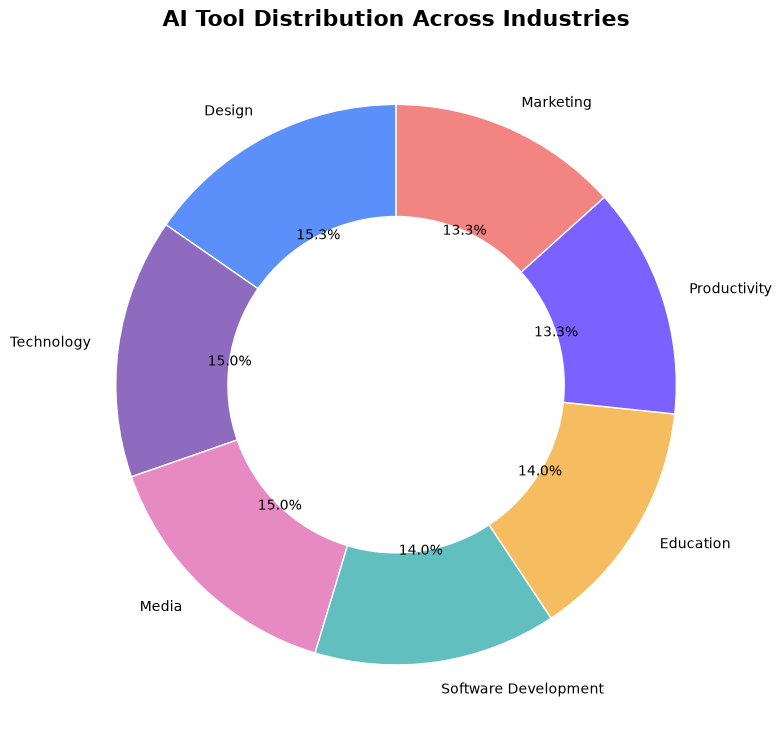

In [57]:
industry_counts = ai_tools["tool_industry"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    industry_counts.values,
    labels=industry_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor="white"),
    colors=[
        "#5B8FF9",
        "#8E6BBE",
        "#E78AC3",
        "#61C0BF",
        "#F6BD60",
        "#7B61FF",
        "#F28482"
    ]
)

plt.title(
    "AI Tool Distribution Across Industries",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Key Insight

The donut chart shows how the AI tools in the dataset are distributed across different industries. It helps identify which industries have a larger representation of AI tools and which industries have comparatively fewer tools.

## Conclusion

This project helped analyze the AI tools ecosystem using different data analysis and visualization techniques.

The analysis covered AI tool categories, popularity, pricing models, industries, launch trends, adoption rates, user segments and main functions.

By working on this project, we can understand how data can be cleaned, combined, analyzed and visualized to find useful patterns and insights from an AI-related dataset.